### Maxmin метод. РО
Братцев А.М. М-Б23

Введите коэффициент альфа: 0.05


[[0.18, -0.31]]


8.535437891520269 0.8050697174779338
[[0.18, -0.31], [14.88, 6.26]] [6.14, 5.8]
T =  22.25928608845437
W =  [[[-1.62, -0.32], [0.03, 0.31], [0.18, -0.31], [-0.89, -0.6], [0.0, 0.12], [-0.32, 0.09], [-0.33, -0.37], [-0.45, 0.63]], [[15.2, 4.88], [13.7, 6.55], [14.84, 6.25], [13.85, 6.18], [14.88, 6.26], [13.7, 6.15], [14.66, 5.17]], [[5.28, 5.26], [6.09, 5.83], [5.81, 5.86], [6.14, 5.8], [5.73, 6.17], [5.53, 5.5]]]


1.8000277775634466 1.1129643044227187
[[0.18, -0.31], [14.88, 6.26], [6.14, 5.8]] [-1.62, -0.32]
T =  20.94516573871171
W =  [[[0.03, 0.31], [0.18, -0.31], [0.0, 0.12], [-0.32, 0.09], [-0.33, -0.37], [-0.45, 0.63]], [[15.2, 4.88], [13.7, 6.55], [14.84, 6.25], [13.85, 6.18], [14.88, 6.26], [13.7, 6.15], [14.66, 5.17]], [[5.28, 5.26], [6.09, 5.83], [5.81, 5.86], [6.14, 5.8], [5.73, 6.17], [5.53, 5.5]], [[-1.62, -0.32], [-0.89, -0.6]]]


1.416615685357182 1.0472582869355855
[[0.18, -0.31], [14.88, 6.26], [6.14, 5.8], [-1.62, -0.32]] [15.2, 4.88]
T =  21.37111

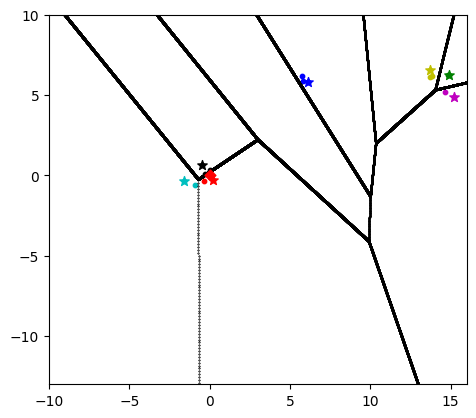

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import random
import math

#random.seed(2)

# Сочетания
def C(n, k):
    return math.factorial(n) / (math.factorial(k) * math.factorial(n - k))

#Расстояния между точками
def ro(xy, Z):
    return np.sqrt((xy[0] - Z[0]) ** 2 + (xy[1] - Z[1]) ** 2)

 
def d(x, Z1, Z2):
    if Z1[1] != Z2[1]:
        return (-(Z1[0] - Z2[0]) * x + (Z1[0] ** 2 +
                                        Z1[1] ** 2 -
                                        Z2[0] ** 2 -
                                        Z2[1] ** 2) / 2) / \
            (Z1[1] - Z2[1])
    else:
        print('Z1' + str(Z1) + 'Z2' + str(Z2))
        raise ZeroDivisionError


def d_func(X, Z1, Z2):
    return (Z1[0] - Z2[0]) * X[0] + (Z1[1] - Z2[1]) * X[1] + (Z2[0] ** 2 + Z2[1] ** 2 - Z1[0] ** 2 - Z1[1] ** 2) / 2


def classify(M, Z, k):
    W = [[] for _ in range(k)] #Множество классов
    for j in range(len(M)):
        norm = []
        for i in range(k):
            norm.append(norma(minus(Z[i], M[j])))

        for i in range(len(norm)):
            if norm[i] == min(norm):
                W[i].append(M[j])
    return W

# Норма
def norma(X):
    return np.sqrt(X[0] ** 2 + X[1] ** 2)

# Разность
def minus(X, Y):
    return [X[0] - Y[0], X[1] - Y[1]]


x = "5,28	6,09	5,81	6,14	5,73	5,53	15,20	13,70	14,84	13,85	14,88	13,70	14,66	-1,62	0,03	0,18	-0,89	0,00	-0,32	-0,33	-0,45"
new_x = x.replace(',', '.')
y = "5,26	5,83	5,86	5,80	6,17	5,50	4,88	6,55	6,25	6,18	6,26	6,15	5,17	-0,32	0,31	-0,31	-0,60	0,12	0,09	-0,37	0,63"
new_y = y.replace(',', '.')
arr_x = list(map(lambda num: float(num), new_x.split()))
arr_y = list(map(lambda num: float(num), new_y.split()))
M = [[cor[0], cor[1]] for cor in zip(arr_x, arr_y)]

#Шаг 1
alpha = float(input("Введите коэффициент альфа:"))
Z = [random.choice(M)]
k = 1
W = [Z[0]]
print(Z)
#Шаг 2: Находим максимально удаленную точку от первого эталона
max_point = 0
index = 0
for i in range(1, len(M)):
    if norma(minus(M[i], Z[0])) > max_point:
        max_point = norma(minus(M[i], Z[0]))
        index = i

Z.append(M[index])
k += 1
# Определили T
T = norma(minus(Z[0], Z[1]))

xkr = []
idx = 0
W = classify(M, Z, k)
# 3 шаг, цикл
while True:
    print(f"\n")
    D = [0] * len(M)
    for j in range(len(M)):
        Di = []
        for i in range(k):
            Di.append(norma(minus(M[j], Z[i])))
        D[j] = min(Di)

    for i in range(len(M)):
        if D[i] == max(D):
            xkr = M[i]
            idx = i
            break
    print(D[idx], alpha * T)
    if D[idx] > alpha * T:
        print(Z, xkr)
        if xkr not in Z:
            Z.append(xkr)
        k += 1
        T = 0 
        for i in range(k):
            for j in range(k):
                if i != j:
                    T += norma(minus(Z[i], Z[j]))
        T /= C(k, 2)  # ** 2
        print('T = ', T)
        W = classify(M, Z, k)
        print('W = ', W)
    else:
        W = classify(M, Z, k)
        print('len(W) = ', len(W))
        break

colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'w', 'orange', 'purple', 'pink', 'brown', 'gray', 'black', 'green', 'blue',
          'cyan', 'magenta', 'yellow', 'olive', 'deepskyblue', 'greenyellow', 'yellowgreen', 'gold', 'lightcoral',
          'lightsalmon']

# Эталоны
print('k =', k)
print('len(Z) =', len(Z))
print('Z =', Z)
print('len(M) =', len(M))
for j in range(len(Z)):
    plt.scatter(Z[j][0], Z[j][1], c=colors[j], marker='*', s=50)


for j in range(k):
    W[j] = np.array(W[j])
    print('len(W[', j, ']) = ', len(W[j]))
    plt.scatter(W[j][:, 0], W[j][:, 1], c=colors[j], s=10)


X = np.arange(-10, 16, 0.001)
points = []
for x in X:
    for i in range(k):
        for j in range(k):
            if i != j:
                y = d(x, Z[i], Z[j])
                xy = np.array([x, y])
                ro1 = ro(xy, Z[i])
                ro2 = ro(xy, Z[j])

                if abs(ro1 - ro2) < 1e-3:
                    ros = []
                    isN = True
                    for s in range(k):
                        if s != i and s != j:
                            ro3 = ro(xy, Z[s])
                            if ro3 < ro1 or ro3 < ro2:
                                isN = False
                    if isN:
                        points.append(xy)

points = np.array(points)
if len(points) != 0:
    plt.scatter(points[:][:, 0], points[:][:, 1], c='black', s=0.1)



# Классификация точки
X = [0, 0]
M1 = [X]
W1 = classify(M1, Z, k)
print('W1 =', W1)
for i in range(k):
    if not W1[i]:
        continue
    else:
        plt.scatter(W1[i][0][0], W1[i][0][1], c=colors[i], s=30, marker='D')


plt.axis('scaled')
plt.xlim(-10, 16)
plt.ylim(-13, 10)

plt.subplot()
plt.show()